1) Sales

Total revenue:

In [23]:
import humanize
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
data_df = pd.read_csv("files/cleaned/olist_final_dataset.csv")
data_df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 'review_id', 'review_score',
       'review_comment_title', 'review_comment_message',
       'review_creation_date', 'review_answer_timestamp',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'seller_zip_code_prefix', 'seller_city', 'seller_state',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'geolocation_zip_code_prefix', 'geolocation_lat',
       'geolocation_lng'],
      dty

In [ ]:
pip install humanize

In [19]:

total_evenue = humanize.intword(data_df['payment_value'].sum().round())
total_evenue

'20.2 million'

Total number of orders:

In [5]:
total_orders = humanize.intword(data_df['order_id'].nunique())
total_orders

'97.9 thousand'

Average order value:  

Average Order Value= Total Revenue​ / Total Number of Orders

In [22]:
revenue = data_df['payment_value'].sum().round()
orders = data_df['order_id'].nunique()
average_orders = round((revenue/ orders), 2)
average_orders

206.19

Monthly sales trend: 

## Sales

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import StrMethodFormatter

In [4]:
data_df['order_purchase_timestamp'] = pd.to_datetime(data_df['order_purchase_timestamp'])
data_df.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                        object
order_delivered_carrier_date             object
order_delivered_customer_date            object
order_estimated_delivery_date            object
order_item_id                             int64
product_id                               object
seller_id                                object
shipping_limit_date                      object
price                                   float64
freight_value                           float64
payment_sequential                        int64
payment_type                             object
payment_installments                      int64
payment_value                           float64
review_id                                object
review_score                              int64
review_comment_title                    

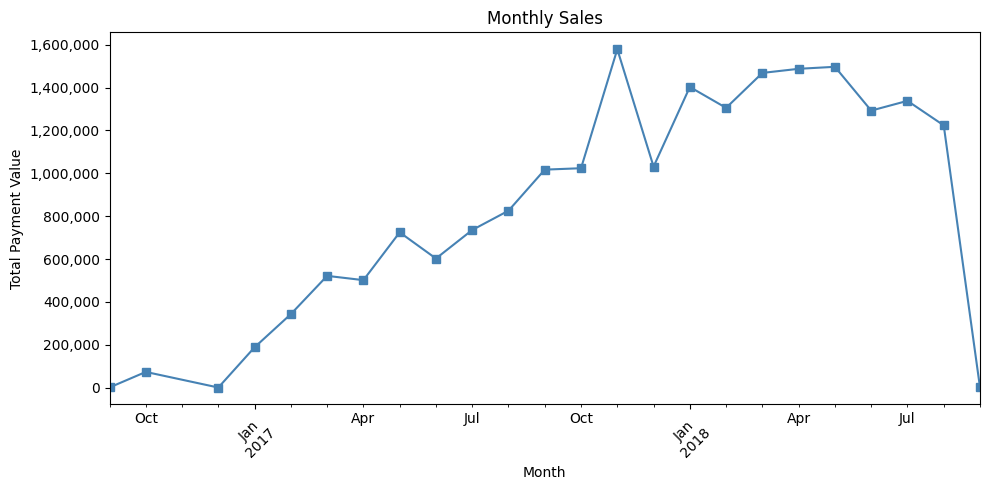

In [ ]:
monthly_sales = (data_df
                 .groupby(data_df["order_purchase_timestamp"].dt.to_period("M"))['payment_value']
                 .sum()
                )
ax = monthly_sales.plot( kind = "line", figsize=(10, 5), marker="s", color="steelblue")
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Total Payment Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Yearly sales trend

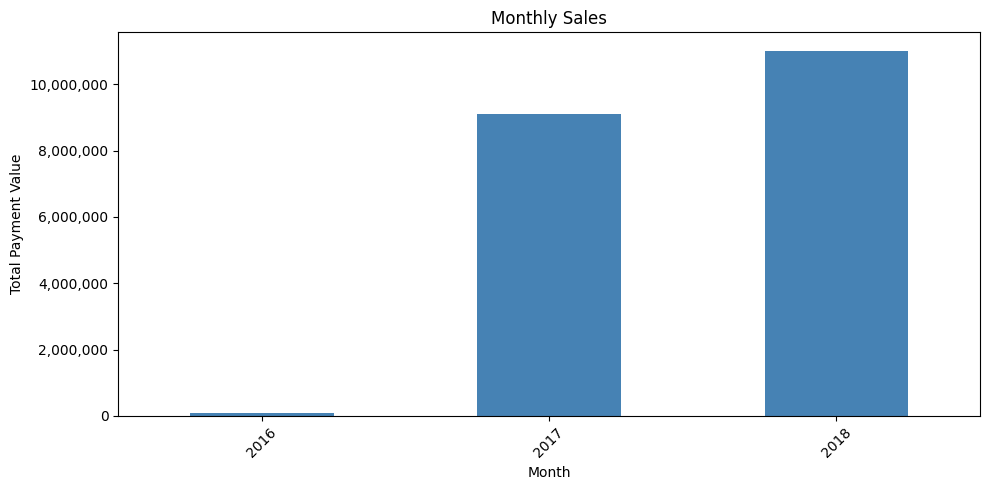

In [56]:
yearly_sales = (data_df
                 .groupby(data_df["order_purchase_timestamp"].dt.to_period("Y"))['payment_value']
                 .sum()
                )
ax = yearly_sales.plot( kind = "bar", figsize=(10, 5), color="steelblue")
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Total Payment Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

 Best month &  Worst month

In [5]:
from functools import reduce
month = (data_df.groupby(data_df["order_purchase_timestamp"].dt.to_period("M"))['payment_value'].sum())
month

best_month = reduce(lambda x,y: x if x[1] >y[1] else y, month.items())[0]
best_month = str(best_month)

print(f"{best_month} is the best month for sales")

worst_month = reduce(lambda x,y: x if x[1]  < y[1] else y, month.items())[0]
worst_month = str(worst_month)

print(f"{worst_month} is the worst month for sales")

2017-11 is the best month for sales
2016-12 is the worst month for sales


## Customers

Number of customers

In [ ]:
data_df['customer_id'] = data_df['customer_id'].astype('string')
Total_customers = data_df['customer_id'].nunique()
Total_customers

97893

Which states have the most customers

In [56]:
more_customer_state = data_df.groupby(['customer_state'])[
    'customer_id'].nunique().idxmax()
more_customer_state

'SP'

Which cities generate the highest revenue

In [ ]:
revenue_by_city = (
    data_df.groupby("customer_state")
    .agg(total_revenue=('payment_value', 'sum'))
    .sort_values(by='total_revenue', ascending=False)
    .idxmax()
)

data_df.groupby()

total_revenue    SP
dtype: object

## Products

Best-selling categories

In [ ]:
data_df.product_category_name

best_selling_products = data_df.groupby(['product_category_name'])['order_item_id'].sum().sort_values(ascending=False).idxmax()
best_selling_products

'cama_mesa_banho'

Lowest-selling categories

In [96]:
lowest_selling_products = data_df.groupby(['product_category_name'])['order_item_id'].sum().sort_values(ascending=True).idxmin()
lowest_selling_products

'seguros_e_servicos'

Average product price

In [ ]:
average_products_price = data_df['price'].mean()
average_products_price

120.52259247261415

Categories with the highest freight cost

In [ ]:
highest_freight_cost = data_df['freight_value'].max()
highest_freight_cost

409.68

## Sellers

Top sellers by revenue

In [124]:
data_df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 'review_id', 'review_score',
       'review_comment_title', 'review_comment_message',
       'review_creation_date', 'review_answer_timestamp',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'seller_zip_code_prefix', 'seller_city', 'seller_state',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'geolocation_zip_code_prefix', 'geolocation_lat',
       'geolocation_lng'],
      dty

In [150]:
top_seller = (data_df.groupby('seller_id').agg(total_revenue=('payment_value', "sum"), product_name=('product_id', 'max')).sort_values(by="total_revenue", ascending=False))
top_seller = top_seller.index[0]

top_seller_category  = (data_df[data_df['seller_id'] == top_seller]['product_category_name']).mode()[0]
top_seller_category 


'moveis_escritorio'

Top sellers city by number of orders

In [157]:
top_seller_by_order = (data_df.groupby('seller_id').agg(total_orders=('order_id', "count"), total_revenue=('payment_value', "sum")).sort_values(by="total_orders", ascending=False))
top_seller_by_order.index[0]

top_seller_by_order = data_df[data_df['seller_id'] == top_seller_by_order.index[0]]['seller_city'].mode()[0]
top_seller_by_order

'ibitinga'

Seller distribution by state

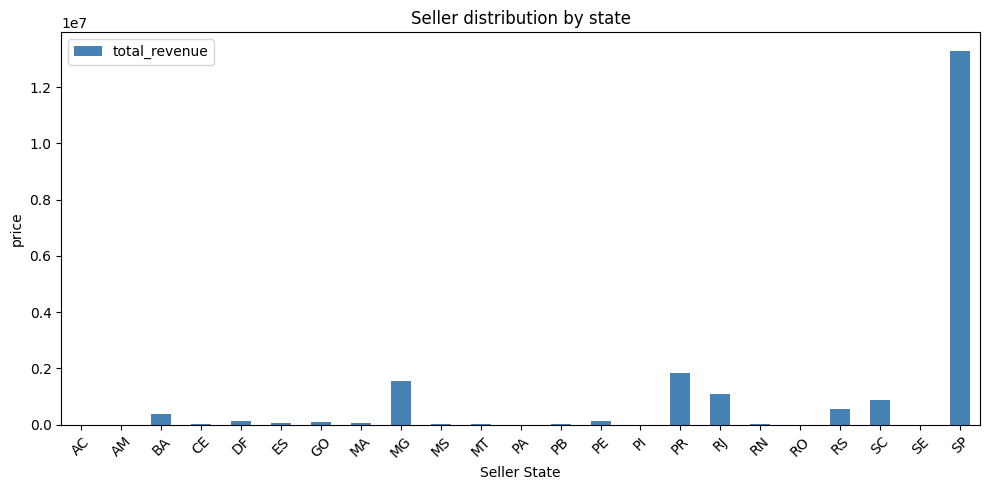

In [171]:
seller_distrubation = (data_df.groupby(['seller_state']).agg(total_revenue=('payment_value', "sum")))
seller_distrubation


ax = seller_distrubation.plot( kind = "bar", figsize=(10, 5), color="steelblue")
plt.title("Seller distribution by state")
plt.xlabel("Seller State")
plt.ylabel("price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Payments

Most used payment method

In [172]:
data_df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 'review_id', 'review_score',
       'review_comment_title', 'review_comment_message',
       'review_creation_date', 'review_answer_timestamp',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'seller_zip_code_prefix', 'seller_city', 'seller_state',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'geolocation_zip_code_prefix', 'geolocation_lat',
       'geolocation_lng'],
      dty

In [ ]:
most_payment = data_df['payment_type'].max()
most_payment

'voucher'

Revenue by payment type

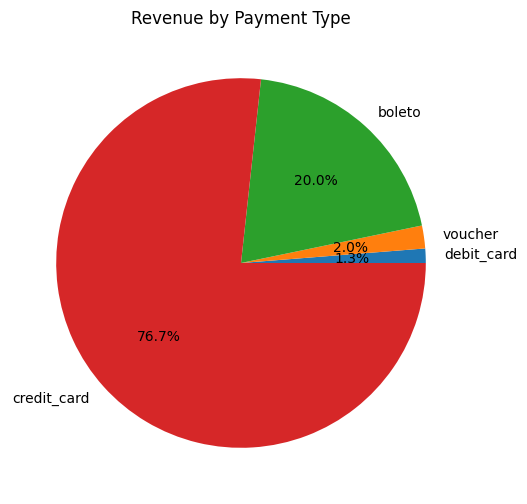

In [201]:
revenue_by_type = (data_df.groupby('payment_type').agg(total_revenue=(
    'payment_value', "sum")).sort_values(by="total_revenue", ascending=True))
revenue_by_type = revenue_by_type.reset_index()
plt.figure(figsize=(6, 6))
plt.pie(revenue_by_type['total_revenue'], labels=revenue_by_type['payment_type'], autopct='%1.1f%%')
plt.title("Revenue by Payment Type")
plt.show()

# Phase 5: Business Questions

Which product categories should receive more investment

Top 10 products which makes huge revenue 

In [216]:
top_category_analysis = (data_df.groupby('product_category_name').agg(total_revenue=("payment_value", 'sum'), total_orders=("order_id", 'count'), average_order_value=(
    "payment_value", "mean"), unique_customers=("customer_unique_id", "nunique")).sort_values(by="total_revenue", ascending=False))
top_category_analysis.head().reset_index()


least_category_analysis = (data_df.groupby('product_category_name').agg(total_revenue=("payment_value", 'sum'), total_orders=("order_id", 'count'), average_order_value=(
    "payment_value", "mean"), unique_customers=("customer_unique_id", "nunique")).sort_values(by="total_revenue"))
least_category_analysis.head().reset_index()

,product_category_name,total_revenue,total_orders,average_order_value,unique_customers
0,seguros_e_servicos,324.51,2,162.255000,2
1,fashion_roupa_infanto_juvenil,785.67,8,98.208750,8
2,cds_dvds_musicais,1199.43,14,85.673571,12
3,casa_conforto_2,1458.54,28,52.090714,22
4,flores,1922.77,31,62.024839,28


<Axes: xlabel='total_revenue', ylabel='product_category_name'>

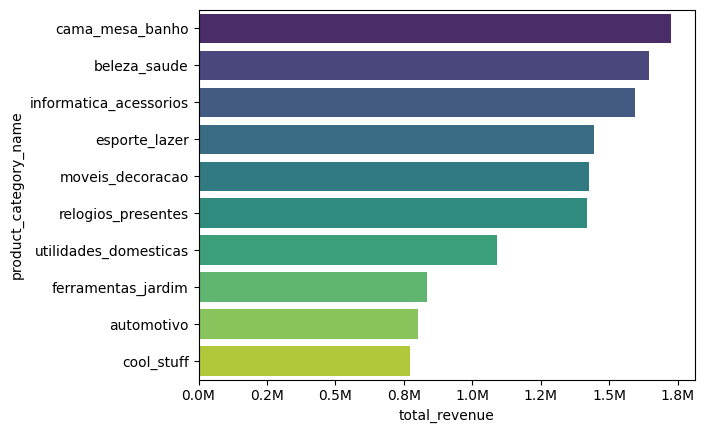

In [217]:
from matplotlib.ticker import FuncFormatter
ax = sns.barplot(data=top_category_analysis.head(10), x="total_revenue", y="product_category_name", hue="product_category_name", palette="viridis", legend=False)

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)

ax

<Axes: xlabel='total_revenue', ylabel='product_category_name'>

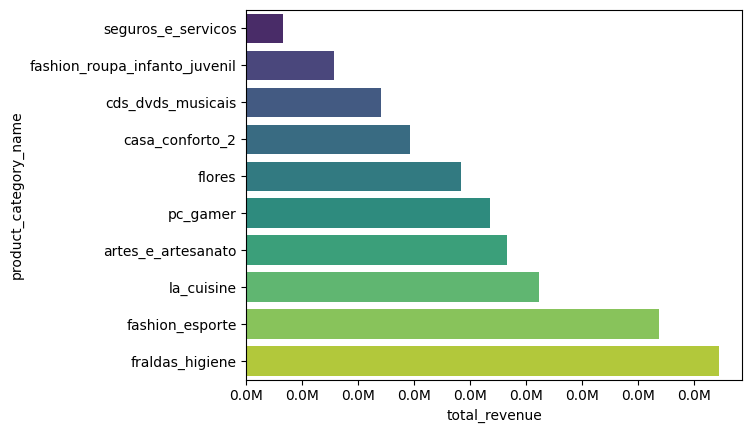

In [218]:
from matplotlib.ticker import FuncFormatter
ax = sns.barplot(data=least_category_analysis.head(10), x="total_revenue", y="product_category_name", hue="product_category_name", palette="viridis", legend=False)

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)

ax

### Customers

top 10 customer state

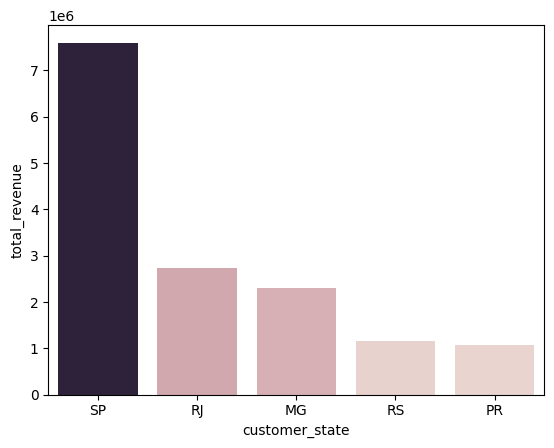

In [ ]:
top_regions =  (data_df.groupby(['customer_state']).agg(total_revenue=("payment_value", 'sum'), total_orders=("order_id", 'count'), average_order_value=(
    "payment_value", "mean"), unique_customers=("customer_unique_id", "nunique"), product_name=("product_category_name", "nunique")).sort_values(by="total_revenue", ascending=False))
top_regions = top_regions.head().reset_index()
sns.barplot(data= top_regions, x = 'customer_state', y = 'total_revenue', hue= 'total_orders')

plt.legend().remove()
plt.show()

### Logistics

Does longer delivery time reduce customer ratings?

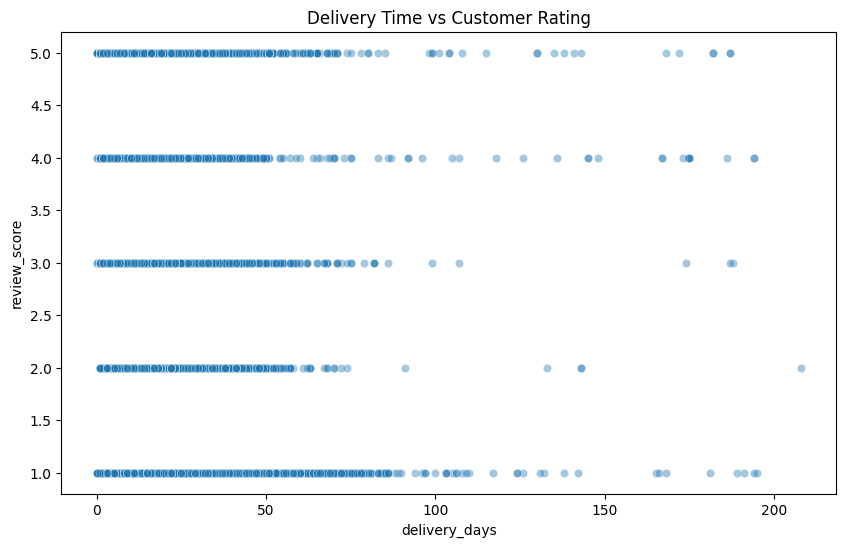

In [248]:
data_df['delivery_days'] = (pd.to_datetime(data_df['order_delivered_customer_date']) - pd.to_datetime(data_df['order_purchase_timestamp'])).dt.days

delivery_days = (data_df.groupby('delivery_days').agg(total_order=('order_id', 'sum'), review_rating=("review_score", "mean")))
delivery_days

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=data_df,
    x='delivery_days',
    y='review_score',
    alpha=0.4
)

plt.title("Delivery Time vs Customer Rating")
plt.show()